In [ ]:
#Import packages
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
from sklearn.tree import plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import roc_auc_score


In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
gameBallot = pd.read_excel("/content/drive/MyDrive/IS670_data/Gaming_Ballot_Data_Set-1.xls")
gameBallot

,State No,County No,FOR,AGAINST,TOTAL CASTE,DEPENDENT VARIABLE,BALLOT TYPE,POPULATION,PCI,MEDIUM FAMILY INCOME,...,UNEMPLOYMENT RATE,AGE LESS THAN 18,AGE24,AGE44,AGE64,AGE OLDER THAN 65,MSA,PERCENT MINORITY,NO OF OLDER,NO OF YOUNGER
0,1,1,42385,22992,65377,1,1,265038,15607,34618,...,5.0,80600,22627,94724,46933,20154,1,0.25,67087,189448
1,1,2,2015,1852,3867,1,1,13617,13740,23114,...,7.0,4285,1861,4092,2114,1265,2,0.40,3379,8184
2,1,3,51959,48406,100365,1,1,391511,24187,44874,...,3.0,111243,29574,150740,70783,29171,1,0.15,99954,301480
3,1,4,957,856,1813,1,1,5345,12816,27359,...,5.0,1647,229,1670,1178,621,2,0.26,1799,3340
4,1,5,942,1129,2071,0,1,4556,19017,23054,...,1.0,1192,220,1231,973,940,2,0.07,1913,2462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282,18,41,44069,27316,71385,1,1,354527,18893,27622,...,15.6,124607,30781,100927,62657,35555,1,0.50,98212,201854
1283,18,42,10026,9755,19781,1,1,53029,20082,33810,...,8.0,11972,3497,16099,12015,9446,2,0.13,21461,32198
1284,18,43,126397,76905,203302,1,1,732143,28711,49763,...,5.6,208062,65744,235177,146412,76748,1,0.38,223160,470354
1285,18,44,26412,23464,49876,1,1,153293,25791,38751,...,5.4,39727,23948,46570,27627,15421,1,0.35,43048,93140


###1. Business Understanding

Voting behavior would come from the basis on how people vote and why they make the decisions that they do. It would involve variables including demographics, social influences,and personal ideology. The behavior voting problem in this case would be a classification problem. Based on previous voter history, we can predict voter turnout to see which factors is the most likely to be voted when it comes to a gaming ballot with gaming and wagering.

Industries that could benefit from a predictive model could include political campaigns and marketing research. Political campaigns would be the most direct, since they could focus on voters who are uncertain and could lean them towards the campaigns direction. Marketing research could improve the the accuracy of public polls as models could be curated towards the clients and provide more valuable insights.

###2. Data Understanding

In order to identify what variables that would need to be defined, we would need to know those variables and their types through this code:

In [ ]:
gameBallot.dtypes

,0
State No,int64
County No,int64
FOR,int64
AGAINST,int64
TOTAL CASTE,int64
DEPENDENT VARIABLE,int64
BALLOT TYPE,int64
POPULATION,int64
PCI,int64
MEDIUM FAMILY INCOME,int64


Each Variable definition:

State No: Primary Key identifying the state. <br>
County No: Primary Key identifying the county. <br>
FOR: Number of "FOR" votes cast.<br>
AGAINST: "AGAINST" votes cast. <br>
TOTAL CASTE: Total number of people who voted. <br>
DEPENDENT VARIABLE: A binary indicator (1 = Yes; 0 = No). <br>
BALLOT TYPE: Identifies the type of ballot (1 = Gambling; 2 = Wagering). <br>
POPULATION: Total population of the county. <br>
PCI: Per capita income.<br>
MEDIUM FAMILY INCOME: The median family income in the county.<br>
SIZE OF COUNTY: The area of the county measured in square miles.<br>
POPULATION DENSITY: The number of people per square mile. <br>
POVERTY LEVEL: The poverty level metric for the county. <br>
UNEMPLOYMENT RATE: unemployment rate in the county.<br>
MSA: Metropolitan Statistical Area binary indicator (1 = Yes; 0 = No). <br>
PERCENT WHITE: Racial distribution showing the percentage of White individuals.<br>
PERCENT BLACK: Racial distribution showing the percentage of Black individuals.<br>
PERCENT OTHER: Racial distribution showing the percentage of individuals of other races.<br>
PERCENT MALE: the percentage of males. <br>
PERCENT FEMALE: the percentage of females.<br>
AGE LESS THAN 18: Age distribution for individuals under 18.<br>
AGE24: Age distribution up to 24<br>
AGE44: Age distribution to 44.<br>
AGE64: Age distribution up to 64. <br>
AGE OLDER THAN 65: Age distribution for individuals 65 and older. <br>
NO OF CHURCHES: total number of churches in the county.<br>
NO OF CHURCH MEMBERS: Number of church members in the county. <br>
PERCENT CHURCH MEMBERS OF POPULATION: Percentage of county's total population that go to a church.<br>
PERCENT MINORITY: Percentage of county's population that would identify as a racial minority <br>
NO OF OLDER: Total of older individiuals living in the county <br>
NO OF YOUNGER: Total of younger individuals in the county.

The problem at hand would be predicting the chances of a county voting either yes or no on a gaming ballot. Within a diverse dataset, these variables would serve to be independent variables that the machine learning models can use to find patterns that we can't see at first. By giving the model these features, it would be able to learn which combinations would lead the target outcome.

In [ ]:
# Change categorical variables to "category"
gameBallot['DEPENDENT VARIABLE'] = gameBallot['DEPENDENT VARIABLE'].astype('category')
gameBallot['BALLOT TYPE'] = gameBallot['BALLOT TYPE'].astype('category')
gameBallot['MSA'] = gameBallot['MSA'].astype('category')

Ten initial charts and their descriptions:

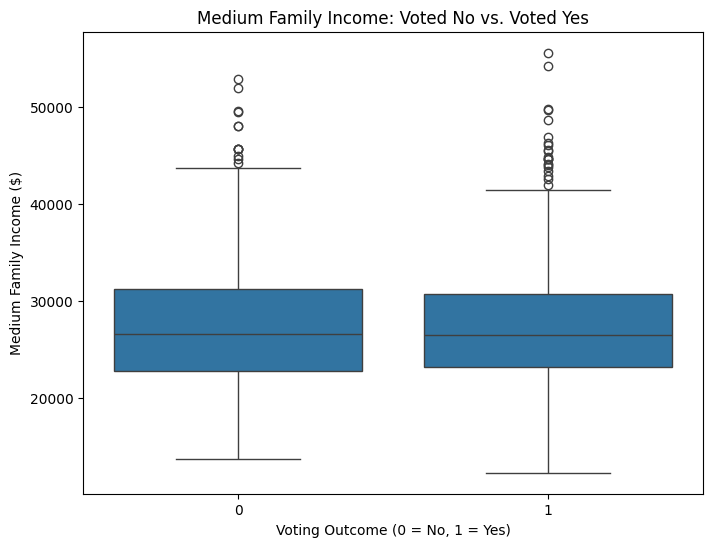

In [ ]:
# Boxplot comparing Medium Family Income against the Dependent Variable
plt.figure(figsize=(8, 6))
sns.boxplot(data=gameBallot, x='DEPENDENT VARIABLE', y='MEDIUM FAMILY INCOME')
plt.title('Medium Family Income: Voted No vs. Voted Yes')
plt.xlabel('Voting Outcome (0 = No, 1 = Yes)')
plt.ylabel('Medium Family Income ($)')
plt.show()

Medium Family Income represents the general wealth of a county. This boxplot would show if the average income of a county that voted "Yes" is higher or lower than that of a county that voted "No". These results show us if wealthier counties are more opposed to gaming or if lower-income areas generally support it.

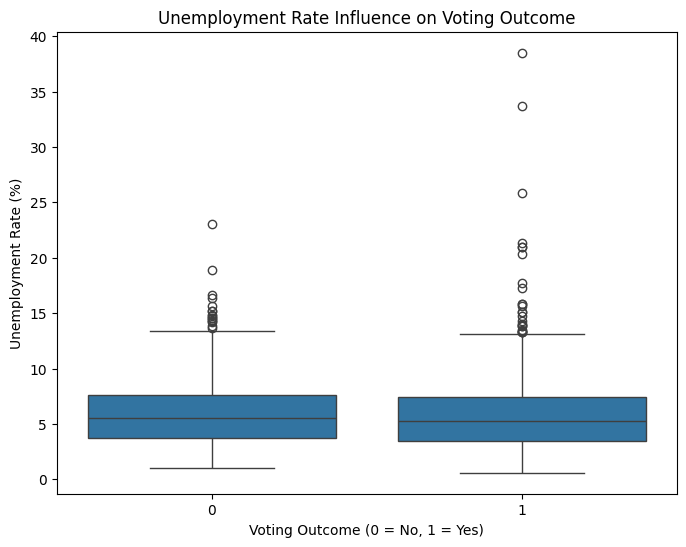

In [ ]:
# Boxplot of Unemployment Rate based on Dependent Variable
plt.figure(figsize=(8, 6))
sns.boxplot(data=gameBallot, x='DEPENDENT VARIABLE', y='UNEMPLOYMENT RATE')
plt.title('Unemployment Rate Influence on Voting Outcome')
plt.xlabel('Voting Outcome (0 = No, 1 = Yes)')
plt.ylabel('Unemployment Rate (%)')
plt.show()

The unemployment rate represents the economic struggles of a county. Gaming and casino ballots are often pitched to voters as massive job creators. Through this boxplot, we can observe whether counties with higher median unemployment rates are more likely to vote in favor of the ballot, which could tell us information that unemployment is a factor if there are more Yes's.

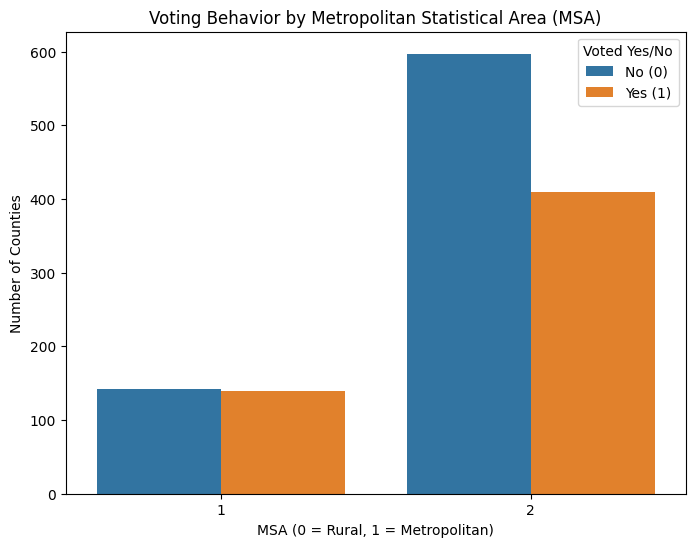

In [ ]:
# Count plot grouped by MSA and split by Dependent Variable
plt.figure(figsize=(8, 6))
sns.countplot(data=gameBallot, x='MSA', hue='DEPENDENT VARIABLE')
plt.title('Voting Behavior by Metropolitan Statistical Area (MSA)')
plt.xlabel('MSA (0 = Rural, 1 = Metropolitan)')
plt.ylabel('Number of Counties')
plt.legend(title='Voted Yes/No', labels=['No (0)', 'Yes (1)'])
plt.show()

Metropolitan Statistical Area (MSA) could be used to view how voting behavior differs between urban and rural areas. Urban areas would tend to have different social views or economic needs compared to rural areas. From this chart, we can  see if being in a metropolitan area makes a county more or less likely to support the gaming ballot.

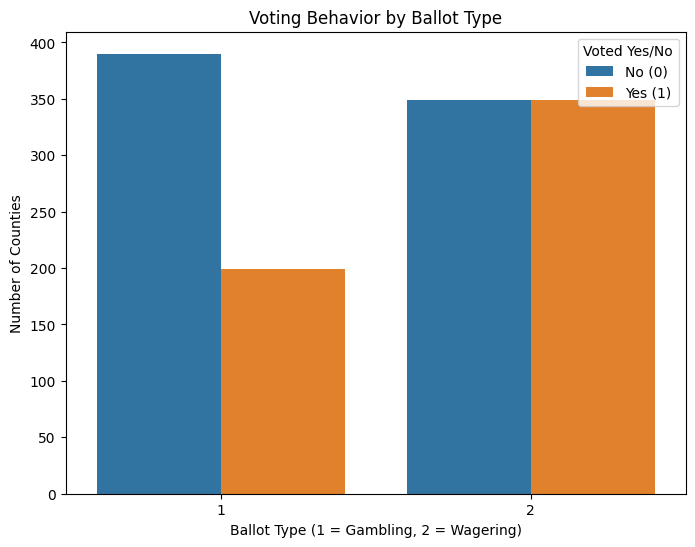

In [ ]:
# Count plot grouped by Ballot Type and split by Dependent Variable
plt.figure(figsize=(8, 6))
sns.countplot(data=gameBallot, x='BALLOT TYPE', hue='DEPENDENT VARIABLE')
plt.title('Voting Behavior by Ballot Type')
plt.xlabel('Ballot Type (1 = Gambling, 2 = Wagering)')
plt.ylabel('Number of Counties')
plt.legend(title='Voted Yes/No', labels=['No (0)', 'Yes (1)'])
plt.show()

Gaming ballots are identified as either Gambling or Wagering. This count plot would analyze if the specific type of ballot affects the voting outcome. Voters lean towards one type over the other due to external cultural differences. From this, we can tell if the ballot type itself is a strong determining factor between yes or no votes.

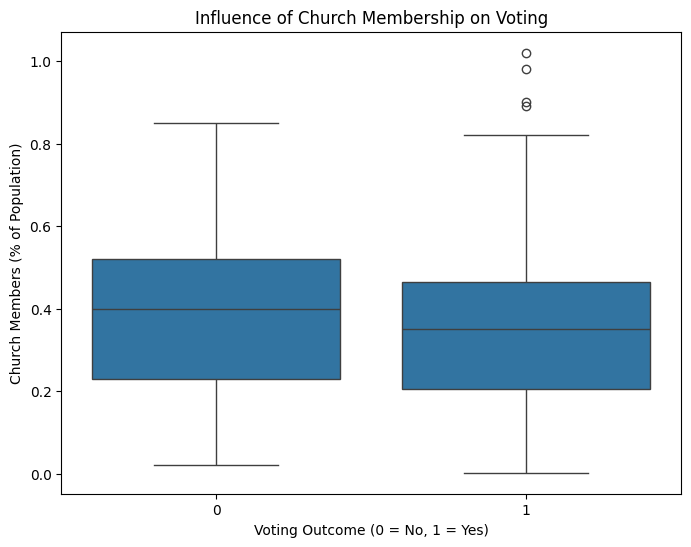

In [ ]:
# Boxplot of % Church Members based on Dependent Variable
plt.figure(figsize=(8, 6))
sns.boxplot(data=gameBallot, x='DEPENDENT VARIABLE', y='PERCENT CHURCH MEMBERS OF POPULATION')
plt.title('Influence of Church Membership on Voting')
plt.xlabel('Voting Outcome (0 = No, 1 = Yes)')
plt.ylabel('Church Members (% of Population)')
plt.show()

Since gaming is often seen as a moral issue, religion could be a factor within the voting outcome. What we can gain from this boxplot is whether areas with a highly religious population would vote against the ballot compared to areas with lower church membership.

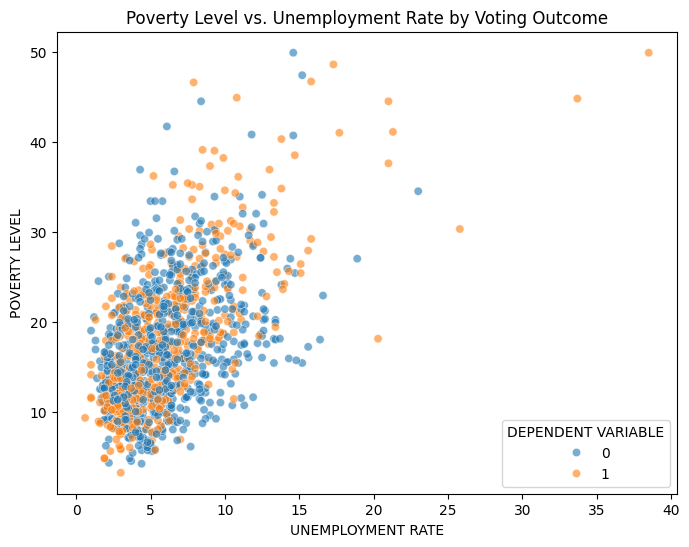

In [ ]:
# Scatterplot of Poverty Level and Unemployment Rate
plt.figure(figsize=(8, 6))
snsplot = sns.scatterplot(x='UNEMPLOYMENT RATE', y='POVERTY LEVEL', data=gameBallot, hue='DEPENDENT VARIABLE', alpha=0.6)
snsplot.set_title("Poverty Level vs. Unemployment Rate by Voting Outcome")
plt.show()

Within the scatterplot, we would be able to see the correlation between a county's poverty level and its unemployment rate. By analyzing these two together, we could perceive if there is a specific section where counties would lean more towards in favor of the gaming ballot as a potential economic remedy due to their economic struggles.

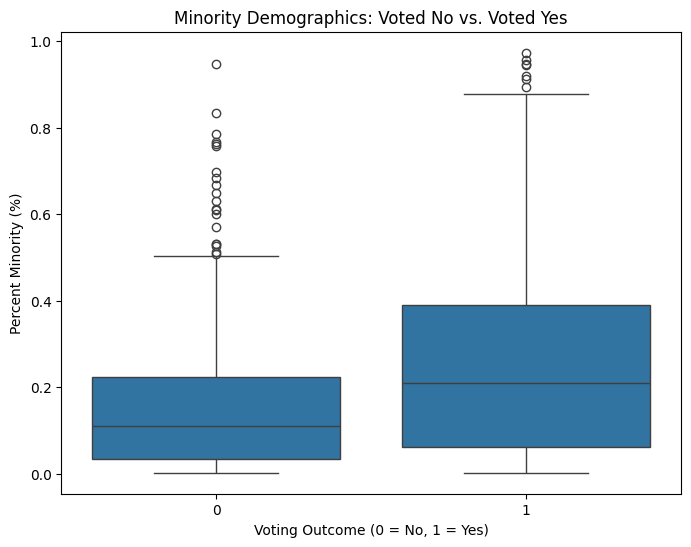

In [ ]:
# Boxplot of Percent Minority against Dependent Variable
plt.figure(figsize=(8, 6))
sns.boxplot(data=gameBallot, x='DEPENDENT VARIABLE', y='PERCENT MINORITY')
plt.title('Minority Demographics: Voted No vs. Voted Yes')
plt.xlabel('Voting Outcome (0 = No, 1 = Yes)')
plt.ylabel('Percent Minority (%)')
plt.show()

This boxplot would analyze the age demographics of a county, specifically the minority, to see if theres any correlation to the voting. Different demographic groups may have different views on gaming or economic status from the other age groups due to cultural differences. We can look at the averages to determine if counties with higher minority populations lean a certain way on the ballot.

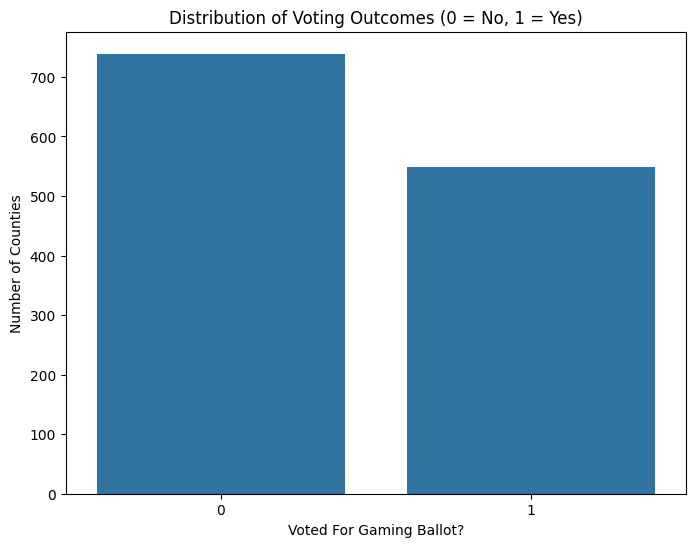

In [ ]:
# Count plot for the target variable (DEPENDENT VARIABLE)
plt.figure(figsize=(8, 6))
sns.countplot(data=gameBallot, x='DEPENDENT VARIABLE')
plt.title('Distribution of Voting Outcomes (0 = No, 1 = Yes)')
plt.xlabel('Voted For Gaming Ballot?')
plt.ylabel('Number of Counties')
plt.show()

The target variable in this dataset is the 'Dependent Variable', which tells us whether a county voted for (1) or against (0) the gaming ballot. This count plot is used for viewing the overall distribution of the voting outcomes. With this, we can also determine if our dataset is balanced or imbalanced.

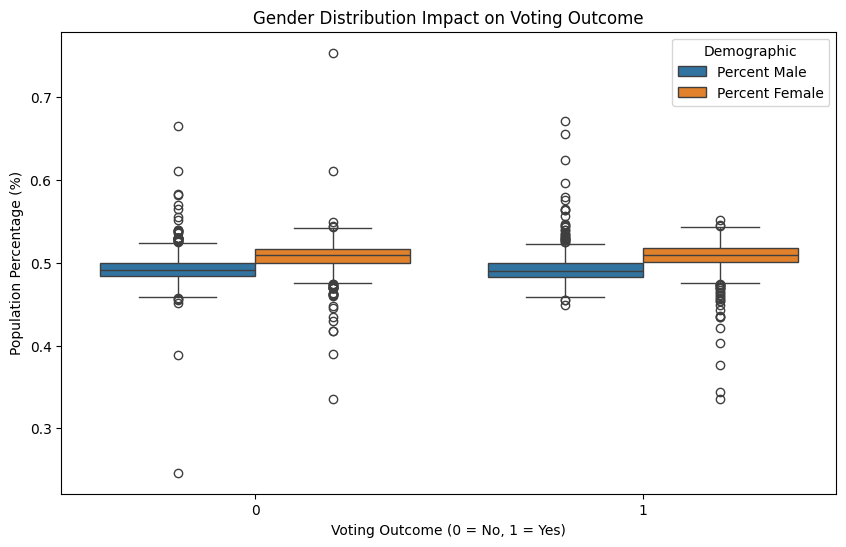

In [ ]:
# boxplot between gender and voting outcome
gender_data = gameBallot[['DEPENDENT VARIABLE', 'PERCENT MALE', 'PERCENT FEMALE']]
gender_melted = pd.melt(gender_data, id_vars=['DEPENDENT VARIABLE'],
                        value_vars=['PERCENT MALE', 'PERCENT FEMALE'],
                        var_name='Gender', value_name='Percentage')

# Legend fix
gender_melted['Gender'] = gender_melted['Gender'].replace({
    'PERCENT MALE': 'Percent Male',
    'PERCENT FEMALE': 'Percent Female'
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=gender_melted, x='DEPENDENT VARIABLE', y='Percentage', hue='Gender')
plt.title('Gender Distribution Impact on Voting Outcome')
plt.xlabel('Voting Outcome (0 = No, 1 = Yes)')
plt.ylabel('Population Percentage (%)')

plt.legend(title='Demographic')
plt.show()

With this boxplot, we would be able to view if gender has any correlation to the voting behavior. If there is a notable difference in IQR's, then it would prove that it is a factor when it comes to voting. This would in turn allow us to know more into which demographic groups are in support or opposition.

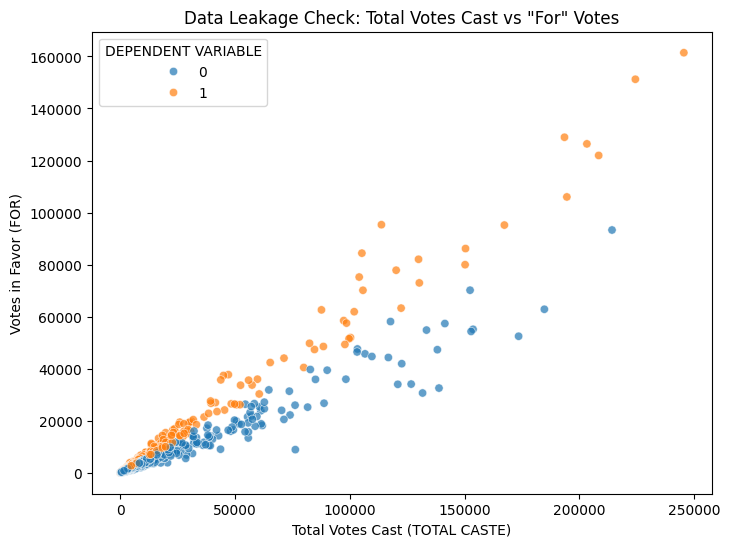

In [ ]:
# Scatterplot of TOTAL CASTE vs FOR votes to illustrate Data Leakage
plt.figure(figsize=(8, 6))
sns.scatterplot(data=gameBallot, x='TOTAL CASTE', y='FOR', hue='DEPENDENT VARIABLE', alpha=0.7)
plt.title('Data Leakage Check: Total Votes Cast vs "For" Votes')
plt.xlabel('Total Votes Cast (TOTAL CASTE)')
plt.ylabel('Votes in Favor (FOR)')
plt.show()

This scatterplot would check for identifying data leakage within the dataset. Variables like 'FOR', 'AGAINST', and 'TOTAL CASTE' are collected after the voting process finished. Because the 'DEPENDENT VARIABLE', the final voting outcome, is determined by whether the FOR votes outnumber the AGAINST votes, including these in our predictive model would be cheating.

As aforementioned, the target variable in this dataset would be 'Dependent Variable'. It is a categorical type and it is also binary as it only has a value of 0 (no) and 1 (yes).

Yes, I do believe that there are variables within the dataset that can help build a meaningful model, though that isn't to say that all of them can be used as predictors. As shown from the charts, there are variables that can lead to valuable information, but there are also some that can appear to be redundant or invaluable. <br>

Some of the variables would include 'FOR', 'AGAINST', and 'TOTAL CASTE' that would need to be dropped since they could be considered as cheating variables. These variables wouldn't be important since they would give their results after the voting concludes, whereas we are trying to build a predictive model of an election before it happens.

###3. Data Preparation

To view if there are any missing values within the variables, we must use the following code:

In [ ]:
gameBallot.isnull().sum()

,0
State No,0
County No,0
FOR,0
AGAINST,0
TOTAL CASTE,0
DEPENDENT VARIABLE,0
BALLOT TYPE,0
POPULATION,0
PCI,0
MEDIUM FAMILY INCOME,0


From this code, we can see that there is 1 missing value in 'NO OF CHURCH MEMBERS' and 1 missing value in 'PERCENT CHURCH MEMBERS OF POPULATION'. This could lead to errors within our modeling if this isn't resolved, so it would be best to handle the missing value using median imputation. Using imputation would calculate the median of the variables and fill in the blanks using that said median. With that said, the following code must be run:

In [ ]:
# Handle the missing value using Median Imputation
median_church = gameBallot_cleaned['PERCENT CHURCH MEMBERS OF POPULATION'].median()
gameBallot_cleaned['PERCENT CHURCH MEMBERS OF POPULATION'] = gameBallot_cleaned['PERCENT CHURCH MEMBERS OF POPULATION'].fillna(median_church)

# Verifying that data is clean
print("\nTotal missing values after handling:")
print(gameBallot_cleaned.isnull().sum().sum())


Total missing values after handling:
0


Moving on, some of the variable types have already been converted previously in the data understanding section, so no further variables would need to be converted for now as they wouldn't be relevant in providing additional insights.

In [ ]:
# Drop Identifiers (No predictive value)
identifiers_drop = ['County No', 'State No']

# Drop Data Leakage / Cheating Variables
leakage_drop = ['FOR', 'AGAINST', 'TOTAL CASTE']

# Drop Highly Correlated / Redundant Variables
correlated_drop = [
    'NO OF OLDER', 'NO OF YOUNGER', 'AGE LESS THAN 18', 'AGE24', 'AGE44', 'AGE64',
    'AGE OLDER THAN 65', 'NO OF CHURCHES', 'NO OF CHURCH MEMBERS'
]

columns_to_drop = identifiers_drop + leakage_drop + correlated_drop
gameBallot_cleaned = gameBallot.drop(columns=columns_to_drop)

print("Remaining columns after dropping unnecessary variables:")
print(gameBallot_cleaned.columns.tolist())

Remaining columns after dropping unnecessary variables:
['DEPENDENT VARIABLE', 'BALLOT TYPE', 'POPULATION', 'PCI', 'MEDIUM FAMILY INCOME', 'SIZE OF COUNTY', 'POPULATION DENSITY', 'PERCENT WHITE', 'PERCENT BLACK', 'PERCENT OTHER', 'PERCENT MALE', 'PERCENT FEMALE', 'PERCENT CHURCH MEMBERS OF POPULATION', 'POVERTY LEVEL', 'UNEMPLOYMENT RATE', 'MSA', 'PERCENT MINORITY']


The identifiers needed to be dropped since they are used only ro identify records within the database, meaning they have no improtance to how people actually vote. If they were to stay, then there could be a chance that they would give an error rather than give any information, leading unnecessary noise being in the dataset. <br>

As aforementioned, 'FOR', 'AGAINST', and 'TOTAL CASTE' would be dropped since they wouldn't provide any insightful information towards a prediction model that can be made, since the information is gathered after the vote has been done. Since our 'DEPENDENT VARIABLE' (the target variable) is calculated by checking if 'FOR' is greater than 'AGAINST', these would let the model "cheat." <br>

The highly correlated variables would beed to be dropped since they would provide similar information to each other (multicollinearity). An example can be the 'POPLUATION' variable already breing represented by the 'AGE' variable, making the population irrelevant towards most analysis.

To view if the data itself is balanced within the target variable, the following code would need to be ran:

In [ ]:
print("Counts for each voting outcome:")
print(gameBallot_cleaned['DEPENDENT VARIABLE'].value_counts())

print("\nPercentage breakdown:")
print(gameBallot_cleaned['DEPENDENT VARIABLE'].value_counts(normalize=True) * 100)

Counts for each voting outcome:
DEPENDENT VARIABLE
0    739
1    548
Name: count, dtype: int64

Percentage breakdown:
DEPENDENT VARIABLE
0    57.420357
1    42.579643
Name: proportion, dtype: float64


From the code results, we could see that the code is sliglhty imbalanced since there are more 0's than 1's. This could ultimately lead to a slight inaccuracy of the models that can be made from this dataset, though it is inevitable due to the nature of this topic since not everyone can agree to a perfect balance of voting. <br>

In order to fix this, an analyst could either undersample, which includes removing random rows of 'YES' vites until it would match the amount of 'NO' votes, or could oversample, to which more 'NO' rows are created to match the amount of 'YES' votes there are.

Now to create dummy coding for the categorical variables, the following code must be ran:

In [ ]:
categorical_cols = gameBallot_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()

# Removes 'DEPENDENT VARIABLE' so it doesn't get affected
if 'DEPENDENT VARIABLE' in categorical_cols:
    categorical_cols.remove('DEPENDENT VARIABLE')

# Perform dummy coding on BALLOT TYPE and MSA variables
gameBallot_cleaned = pd.get_dummies(gameBallot_cleaned, columns=categorical_cols, drop_first=True)

print("Columns after dummy coding:")
print(gameBallot_cleaned.columns.tolist())

Columns after dummy coding:
['DEPENDENT VARIABLE', 'POPULATION', 'PCI', 'MEDIUM FAMILY INCOME', 'SIZE OF COUNTY', 'POPULATION DENSITY', 'PERCENT WHITE', 'PERCENT BLACK', 'PERCENT OTHER', 'PERCENT MALE', 'PERCENT FEMALE', 'PERCENT CHURCH MEMBERS OF POPULATION', 'POVERTY LEVEL', 'UNEMPLOYMENT RATE', 'PERCENT MINORITY', 'BALLOT TYPE_2', 'MSA_2']


In order to prepare our dataset for machine learning models, all variables must be in a numerical format. Algorithms cannot perform mathematical calculations on text or category labels, like "Gambling" vs. "Wagering".<br>

By using the get dummies function, we convert our remaining categorical variables (BALLOT TYPE and MSA) into binary numerical columns. We also  remove our target variable from this list so its format remains untouched.

Furthermore, to create two new engineering features, we must use the following code:

In [ ]:
# 1. Feature: Economic Stress Score
# Multiplying Poverty Level by Unemployment Rate
gameBallot_cleaned['ECONOMIC_STRESS_SCORE'] = gameBallot_cleaned['POVERTY LEVEL'] * gameBallot_cleaned['UNEMPLOYMENT RATE']

# 2. Feature: Gender Gap
# Taking the difference between the male and female population percentages
gameBallot_cleaned['GENDER_GAP'] = abs(gameBallot_cleaned['PERCENT MALE'] - gameBallot_cleaned['PERCENT FEMALE'])

print("Columns after feature engineering:")
print(gameBallot_cleaned[['ECONOMIC_STRESS_SCORE', 'GENDER_GAP']].head())

Columns after feature engineering:
   ECONOMIC_STRESS_SCORE  GENDER_GAP
0                   52.0       0.008
1                  173.6       0.018
2                   17.7       0.024
3                   84.5       0.020
4                   19.0       0.010


Why 'Econmoic Stress Score' can help: Since poverty and unemployment are strong predictors on their own, their combined effect can alter a voting behavior. A county suffering from both high unemployment and high poverty would face economic struggles in comparison to other counties. These specific counties might be much more likely to vote "Yes" on a gaming ballot.<br>

Why 'Gender Gap' can help: Gambling and wagering would have different support levels based on genders. By creating a "Gender Gap" feature, we allow the model to specifically identify counties with different or unique demographics. If heavily male-dominated or female-dominated counties share a distinct voting pattern, this feature will help the Decision Tree models differentiate those splits  faster than evaluating the  percentages of both genders.

###4. Modeling

Now we begin our modeling. First, we must find what are actually the most important variables when it comes to determining the votes within the 'DEPENDENT VARIABLE'. We can do that be entering the code below:

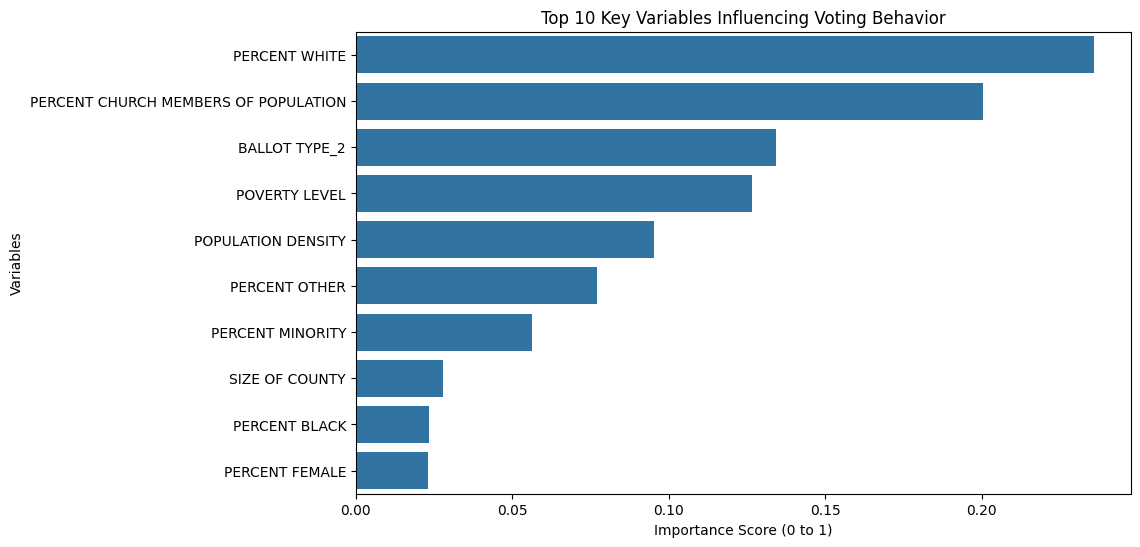

In [ ]:
# Separate the features from the target variable
X = gameBallot_cleaned.drop('DEPENDENT VARIABLE', axis=1)
y = gameBallot_cleaned['DEPENDENT VARIABLE']

# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build the initial Decision Tree model (using max_depth=4 to start)
dt_model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

# Extract and plot the top 10 most important variables
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top_10_importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_importances.values, y=top_10_importances.index)
plt.title('Top 10 Key Variables Influencing Voting Behavior')
plt.xlabel('Importance Score (0 to 1)')
plt.ylabel('Variables')
plt.show()

According to the chart, the strongest predictor in this model is PERCENT WHITE, then  followed further down by PERCENT OTHER, PERCENT MINORITY, and PERCENT BLACK. This would indicate that the racial and demographic of a county is the primary influence of voting behavior. Now we can create our decision tree with the code:

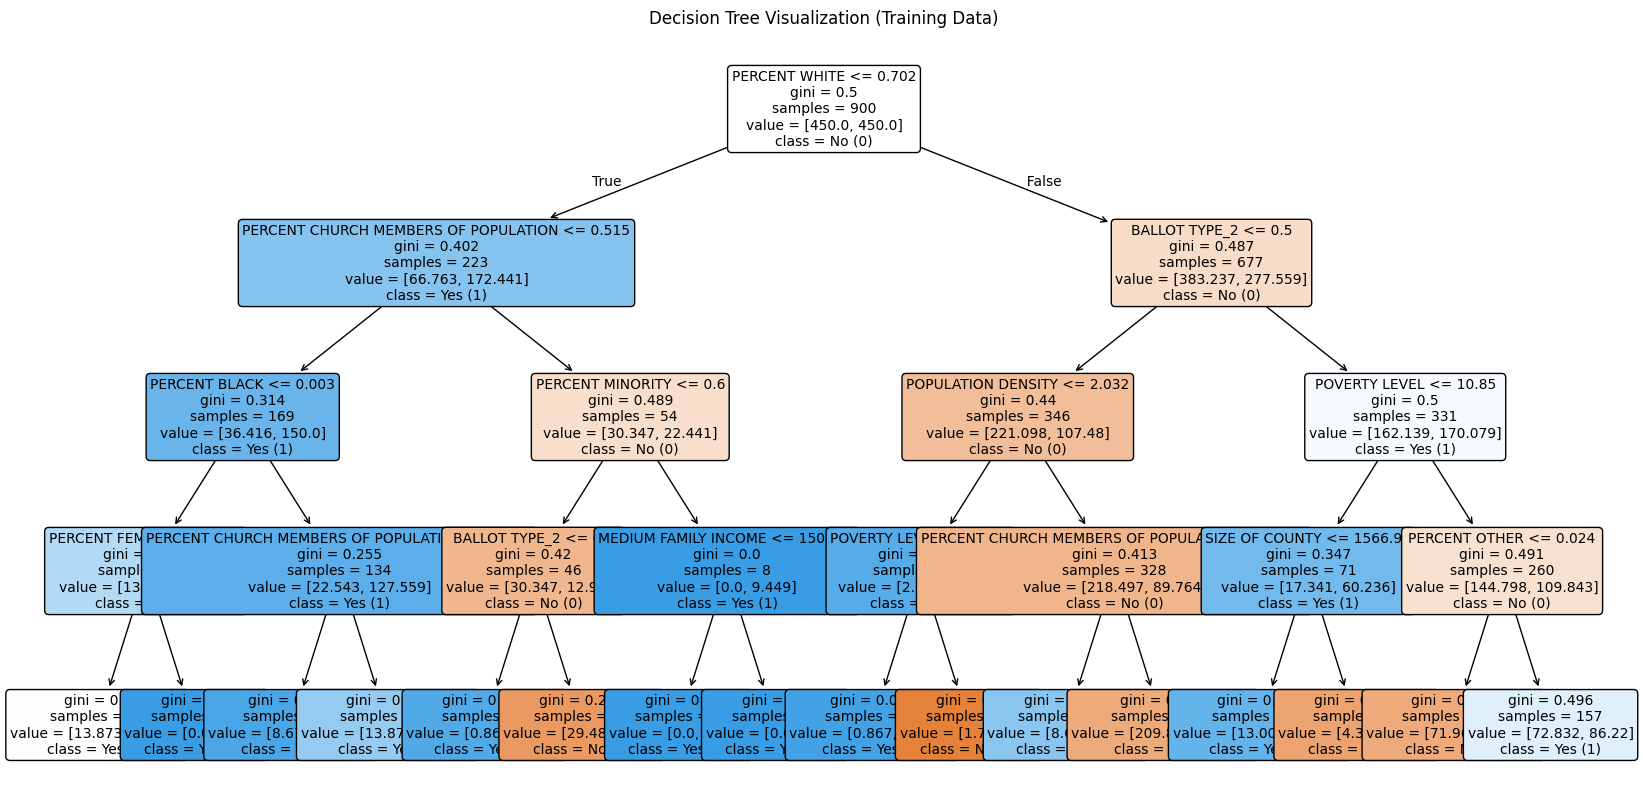

In [ ]:
# Visualizing the Decision Tree from training data
plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=X_train.columns,
          class_names=['No (0)', 'Yes (1)'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization (Training Data)')
plt.show()


Now that a base decision tree has been made, we can create a code that identifies which max depth leads to underfitting, overfitting, and best generalization based on the next code:

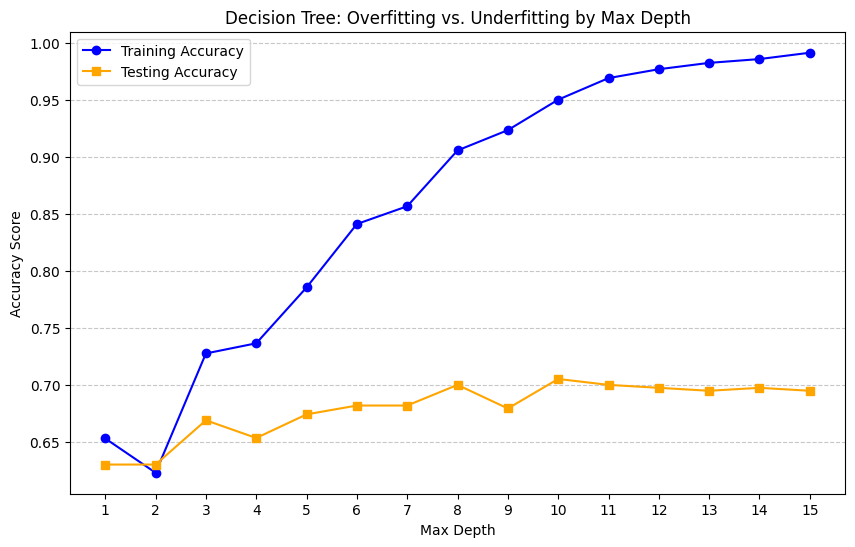

In [ ]:
train_scores = []
test_scores = []

# range of depths to test (from a tree of 1 to a tree of 15)
depth_range = range(1, 16)

for depth in depth_range:
    dt = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    dt.fit(X_train, y_train)

    train_scores.append(dt.score(X_train, y_train))

    test_scores.append(dt.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(depth_range, train_scores, label='Training Accuracy', color='blue', marker='o')
plt.plot(depth_range, test_scores, label='Testing Accuracy', color='orange', marker='s')

plt.title('Decision Tree: Overfitting vs. Underfitting by Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy Score')
plt.xticks(depth_range)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on the chart above, at a max_depth 1 and 2, the model is underfitting because both the training (blue) and testing (orange) accuracies are at their absolute lowest points on the chart. At this stage, the Decision Tree is far too simple; it isn't being allowed enough splits to capture the complex demographic and economic patterns that drive voting behavior. <br>

As the depth increases past 10, the model enters overfitting. The blue training line continues climbing toward nearly 1.00 (100% accuracy), while the orange testing line completely flattens out. This is an indicator that the model has become too complex and has stopped learning any new patterns and has instead started memorizing noise specific to the training dataset.<br>

In terms of generalization, the most optimal model is found where the testing accuracy reaches its peak. Based on the chart, a max_depth of 10 provides the absolute best generalization to the test data, hitting the highest accuracy score on the orange line.

Moving on, we can achieve the model's best performance through tuning it to change the depth and criterion:

In [ ]:
# Initialize variables for best configurations
best_auc = 0
best_config = None
best_dt_model = None

# Loop through both splitting criteria
for criterion in ["gini", "entropy"]:
    # Loop through maximum depths from 2 to 15
    for depth in range(2, 16):
        # Initialize and train the model
        model = DecisionTreeClassifier(criterion=criterion, max_depth=depth, class_weight='balanced', random_state=42)
        model.fit(X_train, y_train)

        # Predict the probability of a "Yes" vote for the test set
        y_prob = model.predict_proba(X_test)[:, 1]

        # Calculate the AUC score
        auc = roc_auc_score(y_test, y_prob)

        # Check combination
        if auc > best_auc:
            best_auc = auc
            best_config = (criterion, depth)
            best_dt_model = model

print(f"Highest AUC Score on Testing Data: {best_auc:.4f}")
print(f"Best Configuration (Criterion, Max Depth): {best_config}")

Highest AUC Score on Testing Data: 0.7050
Best Configuration (Criterion, Max Depth): ('gini', 5)


Through this code, we can see that the best performance can be achieved with a max depth of 5 as it would gain the highest AUC (Area Under Curve) Score of 0.7 with gini as the criterion

Before we begin our KNN modeling, we must also normalize the data due to some variables (such as POPULATION) having larger numbers compared to other smaller variables. We can normalize the data within the following code:

In [ ]:
# (Even though we filled in the missing values earlier, this code would double ensure us that any nulls are filled in)
X_knn_clean = X.fillna(X.median())

# Normalize the predictors using the cleaned data
min_max_scaler = preprocessing.MinMaxScaler()
X_normalized = pd.DataFrame(min_max_scaler.fit_transform(X_knn_clean))
X_normalized.columns = X_knn_clean.columns

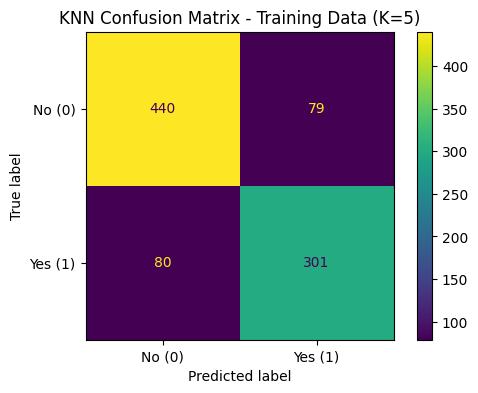

Classification Report - KNN Training Data:

              precision    recall  f1-score   support

      No (0)       0.85      0.85      0.85       519
     Yes (1)       0.79      0.79      0.79       381

    accuracy                           0.82       900
   macro avg       0.82      0.82      0.82       900
weighted avg       0.82      0.82      0.82       900



In [ ]:
#Split the newly normalized data into training and testing
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_normalized, y, test_size=0.3, random_state=42)

# K-Nearest Neighbors model (we'll start off with 5 for now)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_knn, y_train_knn)

# Make predictions on the training data
y_train_pred_knn = knn_model.predict(X_train_knn)

# Confusion Matrix for Training Data
plt.figure(figsize=(6, 4))
cm_knn_train = confusion_matrix(y_train_knn, y_train_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_train, display_labels=['No (0)', 'Yes (1)'])
disp.plot(ax=plt.gca())
plt.title('KNN Confusion Matrix - Training Data (K=5)')
plt.show()

# Classification Report
print("Classification Report - KNN Training Data:\n")
print(classification_report(y_train_knn, y_train_pred_knn, target_names=['No (0)', 'Yes (1)']))

With a KNN of 5 with the training data, the model would actually show to be quite informative. As it has a relatively high precision, recall, f1 score across the board, it shows promise that the model could perform well with the testing data when we move on (at least with a KNN of 5).

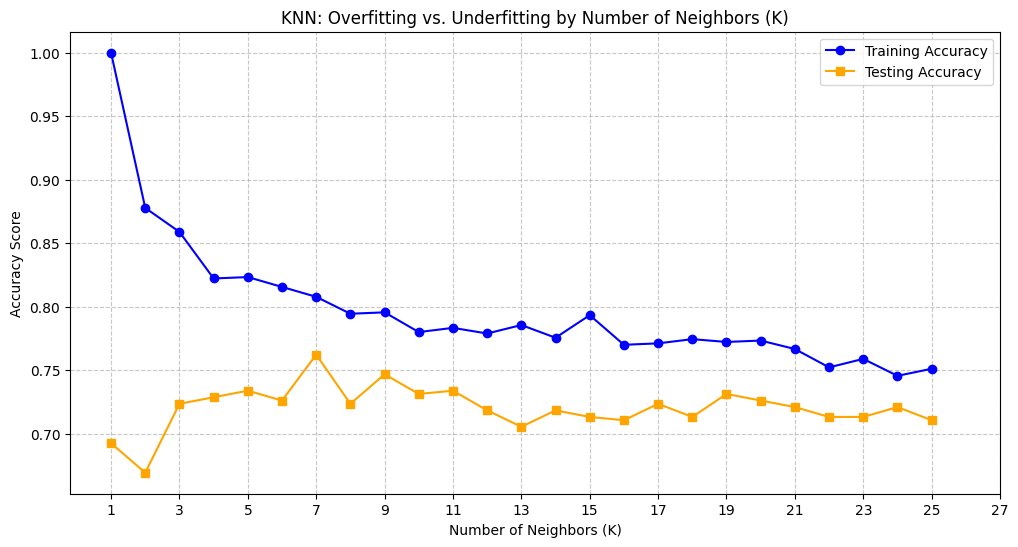

In [ ]:
# Lists of performance metrics
knn_train_scores = []
knn_test_scores = []

# Range of K values to test
k_range = range(1, 26)

for k in k_range:

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_knn)

    # Accuracy on the training data
    knn_train_scores.append(knn.score(X_train_knn, y_train_knn))

    # Accuracy on the unseen testing data
    knn_test_scores.append(knn.score(X_test_knn, y_test_knn))

# Training vs. Testing accuracy for KNN
plt.figure(figsize=(12, 6))
plt.plot(k_range, knn_train_scores, label='Training Accuracy', color='blue', marker='o')
plt.plot(k_range, knn_test_scores, label='Testing Accuracy', color='orange', marker='s')

plt.title('KNN: Overfitting vs. Underfitting by Number of Neighbors (K)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy Score')
plt.xticks(range(1, 28, 2))
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

Overfitting: At extremely low values of K (such as K 1 and 2), the model would be seen as overfitting. The training accuracy would near to perfect, though the testing accuracy would be lower. Because the algorithm is only looking at its 1 or 2 closest neighbors, it is memorizing the specific patterns in the data and outliers of the training set rather than learning new trends.

Underfitting : The model would begin to underfit if the K becomes too large. This would mean that the algorithm loses its ability to see new patterns and becomes too generic, in which it would just guess the majority voting outcome. This can be shown around K=9 as both training and testing accuracy would see a decline.

Best Generalization: The optimal model is found where the testing accuracy reaches its peak, which would be around K=7. This wouldn't be too far off from the K=5 that we had before.

Moving on, now we must run this code to find the best predictive model by testing different K's:

In [ ]:
# Initialize variables to store best performing KNN
best_knn_auc = 0
best_knn_config = None
best_knn_model = None

for weight in ['uniform', 'distance']:
    #  Loop K values from 1 to 25
    for k in range(1, 26):
        # Train the KNN model
        knn = KNeighborsClassifier(n_neighbors=k, weights=weight)
        knn.fit(X_train_knn, y_train_knn)

        # Predict  probability of "Yes" vote for the test set
        y_prob_knn = knn.predict_proba(X_test_knn)[:, 1]

        auc = roc_auc_score(y_test_knn, y_prob_knn)

        # Check highest scores
        if auc > best_knn_auc:
            best_knn_auc = auc
            best_knn_config = (weight, k)
            best_knn_model = knn

print(f"Highest KNN AUC Score on Testing Data: {best_knn_auc:.4f}")
print(f"Best KNN Configuration (Weights, K): {best_knn_config}")

Highest KNN AUC Score on Testing Data: 0.8339
Best KNN Configuration (Weights, K): ('distance', 8)


Classification Report - Best KNN Model (Testing Data):

              precision    recall  f1-score   support

      No (0)       0.76      0.82      0.79       220
     Yes (1)       0.74      0.66      0.70       167

    accuracy                           0.75       387
   macro avg       0.75      0.74      0.74       387
weighted avg       0.75      0.75      0.75       387



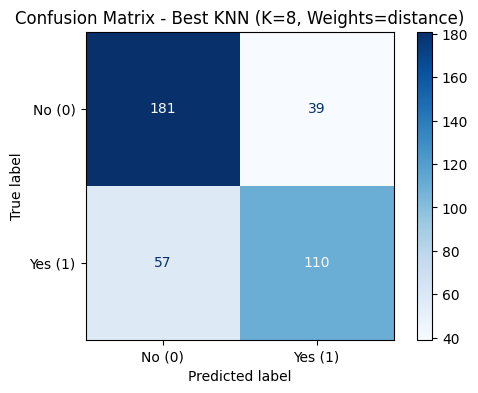

In [ ]:
# Predict on the unseen testing data
y_test_pred_best_knn = best_knn_model.predict(X_test_knn)

# Classification Report
print("Classification Report - Best KNN Model (Testing Data):\n")
print(classification_report(y_test_knn, y_test_pred_best_knn, target_names=['No (0)', 'Yes (1)']))

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm_best_knn = confusion_matrix(y_test_knn, y_test_pred_best_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best_knn, display_labels=['No (0)', 'Yes (1)'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Confusion Matrix - Best KNN (K={best_knn_config[1]}, Weights={best_knn_config[0]})')
plt.show()

Through this coding, we would discover that a K of 8 would have the best predictive performance out of all of the other K's. Overall, the classification report can be seen mostly as above average as the scores would be mostly above 0.70's. In terms of accuracy, 0.75 could be considered towards the stronger side due to the complexities of voting. With precision, the model would pick up the correct amount of votes between yes and no at a similar rate of the mid 0.70's. For the recall, this is where there would be the largest difference between detecting Yes (0.66) and No (0.82). The recall shows that the model would identify 66% as Yes's, though would miss out on 34% that are also actual Yes's. The other notable difference would be the F1 score between Yes (0.7) and No (0.79) as it can be said that the model would be better at idefying counties that would reject the ballot.

Naive Bayes Model:

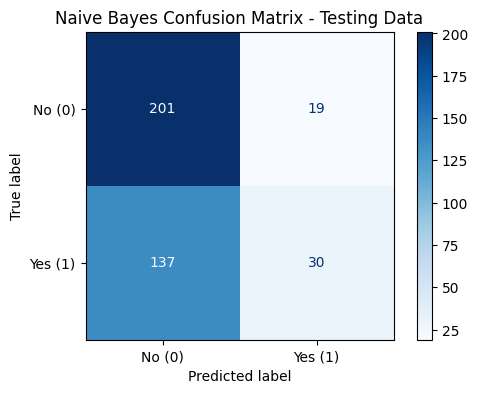

Classification Report - Naive Bayes (Testing Data):

              precision    recall  f1-score   support

      No (0)       0.59      0.91      0.72       220
     Yes (1)       0.61      0.18      0.28       167

    accuracy                           0.60       387
   macro avg       0.60      0.55      0.50       387
weighted avg       0.60      0.60      0.53       387



In [ ]:
# Missing values insurance (similar to before, along with median usage)
X_train_clean = X_train.fillna(X_train.median())
X_test_clean = X_test.fillna(X_train.median())

# Naive Bayes model on training data using GaussianNB
modelNB = GaussianNB()
modelNB.fit(X_train_clean, y_train)

# Predictions on testing data
prediction_on_test_NB = modelNB.predict(X_test_clean)

# Confusion_matrix
plt.figure(figsize=(6, 4))
cm_NB = confusion_matrix(y_test, prediction_on_test_NB)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_NB, display_labels=['No (0)', 'Yes (1)'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Naive Bayes Confusion Matrix - Testing Data')
plt.show()

# Classification report
print("Classification Report - Naive Bayes (Testing Data):\n")
print(classification_report(y_test, prediction_on_test_NB, target_names=['No (0)', 'Yes (1)']))

According to the classification report, the Naive Bayes model would actually perform worse than the KNN models as it would have downgraded scores (with the exception of Recall on No and F1 score on No).

Since we used the Gaussian NB model, the only hyperparameter that could be relevant is var_smoothing, in which it adds a variance to the data to further limit errors during calculations.

The possible ways that this model could be improved is by dropping more variables that could have link to being correlated. We could also transform the data so that it may help calculate probabilities more accurately.

Table comparing each model's metrics with each other:

In [ ]:
# Predictions for models
y_pred_dt = best_dt_model.predict(X_test)
y_pred_knn = best_knn_model.predict(X_test_knn)
y_pred_nb = modelNB.predict(X_test_clean)

# Function to extract and round the metrics for the "Yes" (1)
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1)
    rec = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)
    cm = confusion_matrix(y_true, y_pred)
    # Format confusion matrix
    cm_str = f"TN:{cm[0][0]} FP:{cm[0][1]} FN:{cm[1][0]} TP:{cm[1][1]}"
    return [round(acc, 3), round(prec, 3), round(rec, 3), round(f1, 3), cm_str]

# metric dictionary
metrics_data = {
    'Model': ['Decision Tree ', 'K-Nearest Neighbors ', 'Naive Bayes'],
    'Accuracy': [],
    'Precision (Yes)': [],
    'Recall (Yes)': [],
    'F1-Score (Yes)': [],
    'Confusion Matrix': []
}

for y_true, y_pred in zip([y_test, y_test_knn, y_test], [y_pred_dt, y_pred_knn, y_pred_nb]):
    m = get_metrics(y_true, y_pred)
    metrics_data['Accuracy'].append(m[0])
    metrics_data['Precision (Yes)'].append(m[1])
    metrics_data['Recall (Yes)'].append(m[2])
    metrics_data['F1-Score (Yes)'].append(m[3])
    metrics_data['Confusion Matrix'].append(m[4])

# Table display
comparison_table = pd.DataFrame(metrics_data)
comparison_table.set_index('Model', inplace=True)

print("Model Comparison for Testing Data:")
display(comparison_table)

Model Comparison for Testing Data:


,Accuracy,Precision (Yes),Recall (Yes),F1-Score (Yes),Confusion Matrix
Model,,,,,
Decision Tree,0.674,0.608,0.689,0.646,TN:146 FP:74 FN:52 TP:115
K-Nearest Neighbors,0.752,0.738,0.659,0.696,TN:181 FP:39 FN:57 TP:110
Naive Bayes,0.597,0.612,0.180,0.278,TN:201 FP:19 FN:137 TP:30


From the model comparison, we can see that the KNN model would be the best overall performing model as it would have the highest percentages (except for recall) in comparison to the others. This is due to it being tuned to use distance based weighting to accomplish its results. <br>

The decision tree would place second as it is more viable to overfitting compared to the others, making it perform above average. Even when the max depth is tuned, it would struggle a bit more since it wouldn't generalize the unseen testing data as effictively.<br>

The Naive Bayes model would be the worst out of the bunch as it is shown to have the weakest f1 score (0.28) and the weakest Recall score (0.18) in comparison to the others. The reason the results appear this way is because it would assume that each variable is independent of each other, and would fail to realize the relationships between certain variables.

ROC Curve Chart:

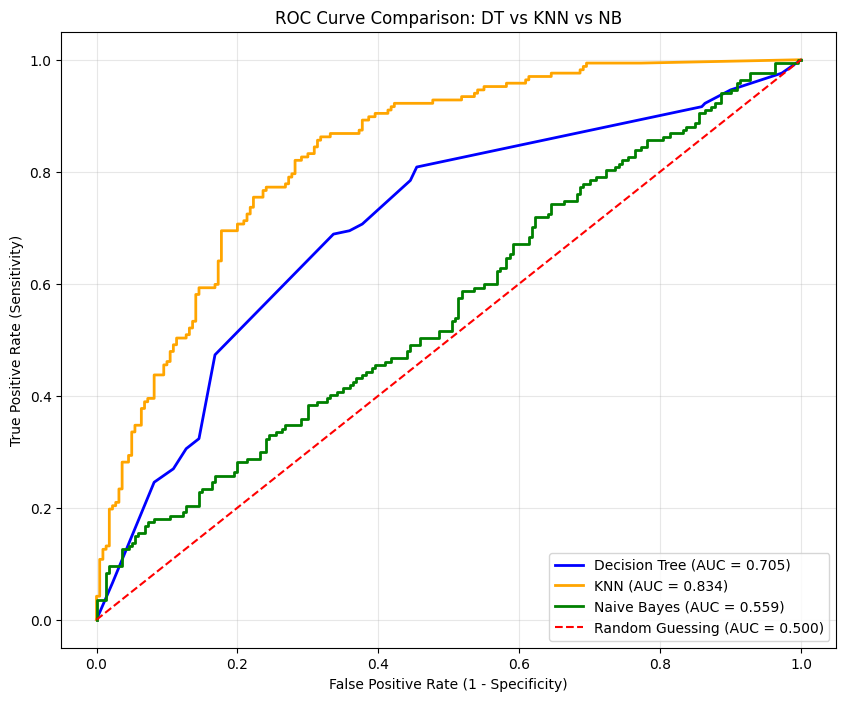

In [ ]:
prob_dt = best_dt_model.predict_proba(X_test)[:, 1]
prob_knn = best_knn_model.predict_proba(X_test_knn)[:, 1]
prob_nb = modelNB.predict_proba(X_test_clean)[:, 1]

# Calculate FPR, TPR, and AUC for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, prob_dt)
auc_dt = roc_auc_score(y_test, prob_dt)

# Calculate FPR, TPR, and AUC for K-Nearest Neighbors
fpr_knn, tpr_knn, _ = roc_curve(y_test_knn, prob_knn)
auc_knn = roc_auc_score(y_test_knn, prob_knn)

# Calculate FPR, TPR, and AUC for Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test, prob_nb)
auc_nb = roc_auc_score(y_test, prob_nb)

plt.figure(figsize=(10, 8))

# Plot each model's curve
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})', color='blue', linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})', color='orange', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})', color='green', linewidth=2)

# Random guessing baseline
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing (AUC = 0.500)')

# Plot actual chart
plt.title('ROC Curve Comparison: DT vs KNN vs NB')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

###5. Evaluation

When using our best model, being KNN, a campaign that would advocate for 'Yes' on a gaming ballot can use them to identify which counties and demographics are most likely to vote for them. This way, they would be able to allocate resources more effectively, which in turn could further improve their campaign rather than having a blind eye in the beginning. The model could help a campaign focus on who's more likely to vote yes on the ballot, making it have a higher chance of winning the next ballot.

Based on the Decision Tree model, the most important variables would be 'PERCENT WHITE', 'PERCENT CHURCH MEMBERS OF POPULATION', 'BALLOT TYPE 2', 'POVERTY LEVEL', and 'POPULATION DENSITY'. The racial demographic is relevant variable since racial demographics would be one of the top factors in modern day voting due to cultural differences and economic needs, plus how different races are viewed by different races in society. The church members population is second relevant as gambling could be seen as unmoral towards religious members, making it something to consider when gathering information on which groups to focus. Ballot Types would be important to note as well because some people might prefer to have gambling rather than wagering, or vice versa depending on the demographics. Then there's poverty level, which is relevant as those in the lower end of the economy would have a different view of the world in comparison to those with money. Finally, the population density could also be seen as relevant as people in different populated areas could have a different outlook on gaming (similar logic to poverty).  

Sensitivity Analysis and Variable Importance:

In [ ]:
# AUC for all 3 models
baseline_auc_dt = roc_auc_score(y_test, best_dt_model.predict_proba(X_test)[:, 1])
baseline_auc_knn = roc_auc_score(y_test_knn, best_knn_model.predict_proba(X_test_knn)[:, 1])
baseline_auc_nb = roc_auc_score(y_test, modelNB.predict_proba(X_test_clean)[:, 1])

# Dictionary to store scores
dt_importances = {}
knn_importances = {}
nb_importances = {}

# 2. Loop through every single feature in our dataset
for feature in X.columns:

    # Decision Tree
    X_train_dt_temp = X_train.drop(columns=[feature])
    X_test_dt_temp = X_test.drop(columns=[feature])
    dt_temp = clone(best_dt_model)
    dt_temp.fit(X_train_dt_temp, y_train)
    auc_dt = roc_auc_score(y_test, dt_temp.predict_proba(X_test_dt_temp)[:, 1])
    dt_importances[feature] = baseline_auc_dt - auc_dt

    # KNN
    X_train_knn_temp = X_train_knn.drop(columns=[feature])
    X_test_knn_temp = X_test_knn.drop(columns=[feature])
    knn_temp = clone(best_knn_model)
    knn_temp.fit(X_train_knn_temp, y_train_knn)
    auc_knn = roc_auc_score(y_test_knn, knn_temp.predict_proba(X_test_knn_temp)[:, 1])
    knn_importances[feature] = baseline_auc_knn - auc_knn

    # Naive Bayes
    X_train_nb_temp = X_train_clean.drop(columns=[feature])
    X_test_nb_temp = X_test_clean.drop(columns=[feature])
    nb_temp = clone(modelNB)
    nb_temp.fit(X_train_nb_temp, y_train)
    auc_nb = roc_auc_score(y_test, nb_temp.predict_proba(X_test_nb_temp)[:, 1])
    nb_importances[feature] = baseline_auc_nb - auc_nb

# Dataframe results
sensitivity_df = pd.DataFrame({
    'Feature': X.columns,
    'DT Importance (AUC Drop)': [dt_importances[f] for f in X.columns],
    'KNN Importance (AUC Drop)': [knn_importances[f] for f in X.columns],
    'NB Importance (AUC Drop)': [nb_importances[f] for f in X.columns]
})

# Average importance of variables within models
sensitivity_df['Average Importance'] = sensitivity_df[['DT Importance (AUC Drop)',
                                                       'KNN Importance (AUC Drop)',
                                                       'NB Importance (AUC Drop)']].mean(axis=1)

sensitivity_df = sensitivity_df.sort_values(by='Average Importance', ascending=False).reset_index(drop=True)

print("Sensitivity Analysis (Leave-One-Feature-Out) Results:")
display(sensitivity_df)

Sensitivity Analysis (Leave-One-Feature-Out) Results:


,Feature,DT Importance (AUC Drop),KNN Importance (AUC Drop),NB Importance (AUC Drop),Average Importance
0,BALLOT TYPE_2,0.037371,0.074143,0.002205,0.037906
1,PERCENT CHURCH MEMBERS OF POPULATION,0.048462,0.024415,0.000109,0.024329
2,POVERTY LEVEL,0.031424,0.022877,0.003647,0.019316
3,PERCENT OTHER,0.030049,0.006233,0.000027,0.012103
4,UNEMPLOYMENT RATE,0.002218,0.010778,0.014017,0.009005
5,PCI,0.000000,0.004586,0.012820,0.005802
6,ECONOMIC_STRESS_SCORE,0.000000,-0.002572,0.007648,0.001692
7,MSA_2,0.000000,0.004164,0.000109,0.001424
8,PERCENT FEMALE,0.000000,0.003865,0.000000,0.001288
9,PERCENT MALE,0.000000,0.002912,0.000000,0.000971


-- Conclusion --

From our findings, the most consistent and important variables would be the percent white, percent minority, percent church members, poverty level, and economic stress score. This would inform us that the results would be influenced by moral and economic backgrounds as religion would defer would have moralities in mind and economies would have monetary values in mind. By using the three models, we could know different measures of thinking when it comes to the ballot. KNN would ultimately find similar counties that would take into account their economies and demogrpahics to relate them to one another. Decision Tree would provide the most amount of logic possible that would drive the votes. Naive Bayes would assume each variable independently, though that wouldn't be realistic in the modern day of society as nothing would be equal (unfortunately), thus making it the weakest model.

Would these models be practical? Yes, they would be in making decisions on what demographics to focus on during a campaign, though one shouldn't be too heavily reliant on them as they are not perfect. While we can use computers all we want to find an outstanding analysis, a computer cannot account for any human error that may happen during a ballot, which could be votes being lost or maybe being fraudulant. In either case, it is better than not having any additional information from when we started the analysis.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Assignment2.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Assignment2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 13 image(s).
[NbConvertApp] Writing 1442576 bytes to /content/drive/MyDrive/Colab Notebooks/Assignment2.html
